# Coursework Template

## Setup

**Dependencies and imports**

This can take a minute...

In [1]:
# !pip install swig
# !pip install rldurham
#!pip install --upgrade rldurham

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""  # disable CUDA (better on Colab/NCC: choose an environment without GPU)
import torch
import rldurham as rld

In [3]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal
import numpy as np
import collections, random

In [ ]:
# References:
# - Haarnoja et al. (2018), Soft Actor-Critic (SAC):
#   motivates the stochastic squashed-Gaussian actor used for bounded continuous actions.
# - Dabney et al. (2018), Distributional Reinforcement Learning with Quantile Regression:
#   motivates predicting quantiles of the return distribution rather than a single scalar Q-value.
# - Ba et al. (2016), Layer Normalization:
#   motivates LayerNorm in the critics to stabilise hidden activations during training.

# TQC Implementation

In [4]:
# ─────────────────────────────────────────────
# Replay Buffer
# ─────────────────────────────────────────────
# References:
# - Mnih et al. (2015), Human-level control through deep reinforcement learning:
#   experience replay improves sample efficiency and reduces temporal correlation in updates.

class ReplayBuffer:
    """Fixed-size replay buffer storing (s, a, r, s2, done)."""

    def __init__(self, capacity: int, obs_dim: int, act_dim: int):
        self.capacity = capacity
        self.ptr = 0
        self.size = 0

        self.s  = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.a  = np.zeros((capacity, act_dim), dtype=np.float32)
        self.r  = np.zeros((capacity, 1),       dtype=np.float32)
        self.s2 = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.d  = np.zeros((capacity, 1),       dtype=np.float32)

    def push(self, s, a, r, s2, done):
        self.s[self.ptr]  = s
        self.a[self.ptr]  = a
        self.r[self.ptr]  = r
        self.s2[self.ptr] = s2
        self.d[self.ptr]  = float(done)

        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size: int):
        idx = np.random.randint(0, self.size, size=batch_size)
        return (
            torch.as_tensor(self.s[idx],  dtype=torch.float32),
            torch.as_tensor(self.a[idx],  dtype=torch.float32),
            torch.as_tensor(self.r[idx],  dtype=torch.float32),
            torch.as_tensor(self.s2[idx], dtype=torch.float32),
            torch.as_tensor(self.d[idx],  dtype=torch.float32),
        )

    def __len__(self):
        return self.size

In [5]:
# ─────────────────────────────────────────────
# Network Definitions
# ─────────────────────────────────────────────

def mlp(in_dim: int, out_dim: int, hidden: int = 400):
    return nn.Sequential(
        nn.Linear(in_dim, hidden), nn.LayerNorm(hidden), nn.ReLU(),
        nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.ReLU(),
        nn.Linear(hidden, out_dim),
    )


class Actor(nn.Module):
    """
    SAC-style squashed Gaussian actor.
    CHANGED: flat MLP taking full observation vector directly.
    No lidar split — lets the network learn its own feature interactions.
    """

    LOG_STD_MIN = -5
    LOG_STD_MAX = 2

    def __init__(self, obs_dim: int, act_dim: int, hidden: int = 400):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),  nn.ReLU(),
        )

        self.mu_head      = nn.Linear(hidden, act_dim)
        self.log_std_head = nn.Linear(hidden, act_dim)

    def forward(self, s):
        h = self.net(s)
        mu      = self.mu_head(h)
        log_std = self.log_std_head(h).clamp(self.LOG_STD_MIN, self.LOG_STD_MAX)
        return mu, log_std

    def sample(self, s):
        """
        Returns:
          a     : (B, act_dim) tanh-squashed actions in [-1, 1]
          logpi : (B, 1)       log probability with tanh correction
        """
        mu, log_std = self.forward(s)
        std  = log_std.exp()
        dist = Normal(mu, std)

        x = dist.rsample()           # reparameterised sample (pre-tanh)
        a = torch.tanh(x)

        # Log prob with tanh squashing correction (SAC, Haarnoja et al. 2018, App. C)
        logp  = dist.log_prob(x).sum(dim=-1, keepdim=True)
        logp -= torch.log(1 - a.pow(2) + 1e-6).sum(dim=-1, keepdim=True)
        return a, logp

    @torch.no_grad()
    def act(self, s, deterministic=False):
        mu, log_std = self.forward(s)
        if deterministic:
            return torch.tanh(mu)
        x = Normal(mu, log_std.exp()).sample()
        return torch.tanh(x)


class QuantileCritic(nn.Module):
    """
    Distributional critic using quantile regression (QR-DQN style).
    CHANGED: flat MLP taking full [observation, action] directly.
    No lidar split. LayerNorm retained via mlp() helper.
    """

    def __init__(self, obs_dim: int, act_dim: int, n_quantiles: int, hidden: int = 400):
        super().__init__()
        self.n_quantiles = n_quantiles
        self.net = mlp(obs_dim + act_dim, n_quantiles, hidden)

    def forward(self, s, a):
        x = torch.cat([s, a], dim=-1)   # (B, obs_dim + act_dim)
        return self.net(x)               # (B, n_quantiles)

In [6]:
# References:
# - Ioffe and Szegedy (2015), Batch Normalization:
#   general motivation for keeping inputs well-scaled during optimisation.
#
# Note:
# This implementation uses running normalisation of environment observations,
# not BatchNorm inside the network.

class RunningNormalizer:
    def __init__(self, dim, epsilon=1e-8):
        self.mean = np.zeros(dim, dtype=np.float32)
        self.var  = np.ones(dim,  dtype=np.float32)
        self.count = 0
        self.epsilon = epsilon

    def update(self, x):
        self.count += 1
        alpha = 1.0 / self.count
        delta = x - self.mean
        self.mean += alpha * delta
        self.var   = (1 - alpha) * self.var + alpha * delta * (x - self.mean)

    def normalize(self, x):
        return (x - self.mean) / (np.sqrt(self.var) + self.epsilon)

In [7]:

# ─────────────────────────────────────────────
# TQC Agent
# ─────────────────────────────────────────────
#
# Changes from TQC-7:
#   1. Flat MLP — no lidar split in Actor or Critics
#   2. TOP_DROP_PER: 3 → 2 (paper recommendation for Walker)
#   3. Reward upscaling: r * 5.0 (amplifies reward signal relative to entropy)
#
# Retained from TQC-7:
#   - HIDDEN=400, UPDATES_PER_STEP=2
#   - Entropy annealing from -4.0 to -7.0 over 800k steps
#   - Median actor objective
#   - Truncation fix (storing terminated not done)
#   - Observation normalisation + LayerNorm in critics
#   - Gradient clipping at 1.0

# References:
# - Kuznetsov et al. (2020), Truncated Quantile Critics (TQC):
#   target quantiles from all critics are pooled, sorted, and the most optimistic
#   values are dropped to reduce overestimation bias.
# - Haarnoja et al. (2018), Soft Actor-Critic (SAC):
#   provides the entropy-regularised actor objective and automatic temperature tuning.
# - Fujimoto et al. (2018), TD3:
#   motivates delayed policy updates for improved stability.
# - Lillicrap et al. (2015), DDPG:
#   motivates soft target-network updates via Polyak averaging.


class Agent(nn.Module):
    """
    TQC with flat MLP architecture:
      - N critics, each outputs Nq quantiles
      - Target uses pooled quantiles from all target critics, sorted, top dropped
      - Critic loss uses quantile regression (Huber)
      - Actor + alpha same as SAC
    """

    # ---- Hyperparameters ----
    N_CRITICS    = 5
    N_QUANTILES  = 25
    TOP_DROP_PER = 2           

    LR_ACTOR  = 3e-4
    LR_CRITIC = 3e-4
    LR_ALPHA  = 3e-4

    GAMMA = 0.99
    TAU   = 0.005

    BUFFER_SIZE  = int(1e6)
    BATCH_SIZE   = 256
    WARMUP_STEPS = 10_000

    UPDATES_PER_STEP = 2
    POLICY_DELAY     = 2

    HIDDEN    = 400
    GRAD_CLIP = 1.0

    REWARD_SCALE = 5.0         

    # --- Entropy annealing schedule ---
    TARGET_ENTROPY_START = -4.0
    TARGET_ENTROPY_END   = -7.0
    ENTROPY_DECAY_STEPS  = 800_000

    def __init__(self, env):
        super().__init__()

        self.discrete_act, self.discrete_obs, self.act_dim, self.obs_dim = rld.env_info(env)
        assert not self.discrete_act, "TQC requires continuous action space."
        assert not self.discrete_obs, "This implementation assumes vector observations."

        # Networks — flat MLP, no lidar split
        self.actor = Actor(self.obs_dim, self.act_dim, self.HIDDEN)

        self.critics = nn.ModuleList([
            QuantileCritic(self.obs_dim, self.act_dim, self.N_QUANTILES, self.HIDDEN)
            for _ in range(self.N_CRITICS)
        ])
        self.critics_target = nn.ModuleList([
            QuantileCritic(self.obs_dim, self.act_dim, self.N_QUANTILES, self.HIDDEN)
            for _ in range(self.N_CRITICS)
        ])
        for c, ct in zip(self.critics, self.critics_target):
            ct.load_state_dict(c.state_dict())
            for p in ct.parameters():
                p.requires_grad = False

        # Entropy temperature
        self.target_entropy = self.TARGET_ENTROPY_START
        self.log_alpha = torch.zeros(1, requires_grad=True)
        self.alpha = self.log_alpha.exp().item()

        # Optimisers
        self.actor_opt  = optim.Adam(self.actor.parameters(), lr=self.LR_ACTOR)
        self.critic_opt = optim.Adam([p for c in self.critics for p in c.parameters()], lr=self.LR_CRITIC)
        self.alpha_opt  = optim.Adam([self.log_alpha], lr=self.LR_ALPHA)

        # Replay buffer
        self.buffer = ReplayBuffer(self.BUFFER_SIZE, self.obs_dim, self.act_dim)

        # Quantile midpoints taus: (i+0.5)/N
        taus = (torch.arange(self.N_QUANTILES, dtype=torch.float32) + 0.5) / self.N_QUANTILES
        self.taus = taus.view(1, self.N_QUANTILES, 1)  # (1, Nq, 1)

        # Counters
        self.total_steps = 0
        self.episode_steps = 0
        self.total_updates = 0

        self.obs_normalizer = RunningNormalizer(self.obs_dim)

    # --------------------------------------------------------
    # Template interface
    # --------------------------------------------------------

    def sample_action(self, s):
        self.obs_normalizer.update(np.array(s, dtype=np.float32))

        if self.total_steps < self.WARMUP_STEPS:
            return (torch.rand(self.act_dim) * 2 - 1)

        s_norm = torch.as_tensor(
            self.obs_normalizer.normalize(np.array(s, dtype=np.float32)),
            dtype=torch.float32
        ).unsqueeze(0)
        with torch.no_grad():
            a, _ = self.actor.sample(s_norm)
        return a.squeeze(0)

    def put_data(self, s, a, r, s2, done):
        a_np = a.detach().cpu().numpy().astype(np.float32) if isinstance(a, torch.Tensor) else np.array(a, dtype=np.float32)

        self.buffer.push(
            np.array(s, dtype=np.float32),
            a_np,
            float(r) * self.REWARD_SCALE,    # CHANGED: reward upscaling by 5
            np.array(s2, dtype=np.float32),
            float(done),
        )
        self.total_steps += 1
        self.episode_steps += 1

    def train(self):
        """
        Called once per episode by the template loop.
        We do UPDATES_PER_STEP * episode_steps gradient updates.
        """
        if self.total_steps < self.WARMUP_STEPS:
            self.episode_steps = 0
            return
        if len(self.buffer) < self.BATCH_SIZE:
            self.episode_steps = 0
            return

        n_updates = self.UPDATES_PER_STEP * self.episode_steps
        for _ in range(n_updates):
            self._update()

        self.episode_steps = 0

    # --------------------------------------------------------
    # Core update
    # --------------------------------------------------------

    def _update(self):
        s, a, r, s2, d = self.buffer.sample(self.BATCH_SIZE)

        s_np  = s.numpy()
        s2_np = s2.numpy()
        s_norm  = torch.as_tensor(
            self.obs_normalizer.normalize(s_np), dtype=torch.float32)
        s2_norm = torch.as_tensor(
            self.obs_normalizer.normalize(s2_np), dtype=torch.float32)

        # -------------------------------------------------
        # 0) Anneal target entropy
        # -------------------------------------------------
        progress = min(self.total_steps / self.ENTROPY_DECAY_STEPS, 1.0)
        self.target_entropy = (
            self.TARGET_ENTROPY_START
            + progress * (self.TARGET_ENTROPY_END - self.TARGET_ENTROPY_START)
        )

        # -------------------------
        # 1) Build truncated target quantiles
        # -------------------------
        with torch.no_grad():
            a2, log_pi2 = self.actor.sample(s2_norm)
            z2 = torch.stack([ct(s2_norm, a2) for ct in self.critics_target], dim=1)

            z2 = z2.view(self.BATCH_SIZE, -1)  # (B, C*Nq)

            # Sort and drop the top tail (largest)
            total = self.N_CRITICS * self.N_QUANTILES
            total_drop = self.N_CRITICS * self.TOP_DROP_PER
            assert 0 <= total_drop < total

            z2_sorted, _ = torch.sort(z2, dim=1)
            z2_trunc = z2_sorted[:, : total - total_drop]

            # SAC-style entropy term
            alpha = self.log_alpha.exp()
            target_z = z2_trunc - alpha * log_pi2

            # Bellman backup
            y = r + self.GAMMA * (1 - d) * target_z

        # -------------------------
        # 2) Critic update (quantile regression)
        # -------------------------
        critic_loss = 0.0
        for c in self.critics:
            z = c(s_norm, a)  # (B, Nq)

            # Pairwise TD errors: (B, Nq, Kt)
            z_i = z.unsqueeze(2)
            y_j = y.unsqueeze(1)
            td = y_j - z_i

            # Huber loss
            abs_td = td.abs()
            delta = 1.0
            huber = torch.where(
                abs_td <= delta,
                0.5 * td.pow(2),
                delta * (abs_td - 0.5 * delta)
            )

            # Quantile weights: |tau - I[td<0]|
            weight = torch.abs(self.taus - (td.detach() < 0).float())

            # Mean over target samples, sum over quantiles, mean over batch
            qloss = (weight * huber).mean(dim=2).sum(dim=1).mean()
            critic_loss = critic_loss + qloss

        self.critic_opt.zero_grad(set_to_none=True)
        critic_loss.backward()
        if self.GRAD_CLIP is not None:
            torch.nn.utils.clip_grad_norm_([p for c in self.critics for p in c.parameters()], self.GRAD_CLIP)
        self.critic_opt.step()

        # -------------------------
        # 3) Delayed actor + alpha updates
        # -------------------------
        if (self.total_updates % self.POLICY_DELAY) == 0:
            a_new, log_pi = self.actor.sample(s_norm)

            # Median across critics
            z_new = torch.stack([c(s_norm, a_new) for c in self.critics], dim=1)  # (B, 5, 25)
            q_per_critic = z_new.mean(dim=2)                                      # (B, 5)
            q_median = q_per_critic.median(dim=1, keepdim=True).values            # (B, 1)

            alpha = self.log_alpha.exp()
            actor_loss = (alpha * log_pi - q_median).mean()

            self.actor_opt.zero_grad(set_to_none=True)
            actor_loss.backward()
            if self.GRAD_CLIP is not None:
                torch.nn.utils.clip_grad_norm_(self.actor.parameters(), self.GRAD_CLIP)
            self.actor_opt.step()

            # Temperature update (uses annealed target_entropy)
            alpha_loss = -(self.log_alpha * (log_pi.detach() + self.target_entropy)).mean()
            self.alpha_opt.zero_grad(set_to_none=True)
            alpha_loss.backward()
            self.alpha_opt.step()

            self.alpha = self.log_alpha.exp().item()

        # -------------------------
        # 4) Soft update targets
        # -------------------------
        with torch.no_grad():
            for c, ct in zip(self.critics, self.critics_target):
                for p, pt in zip(c.parameters(), ct.parameters()):
                    pt.data.mul_(1 - self.TAU)
                    pt.data.add_(self.TAU * p.data)

        self.total_updates += 1

## Training

**Prepare the environment and wrap it to capture statistics, logs, and videos**

The device is: cpu (as recommended)
actions are continuous with 4 dimensions/#actions
observations are continuous with 24 dimensions/#observations
maximum timesteps is: 2000


/opt/anaconda3/envs/ReinforcementLearningCoursework/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


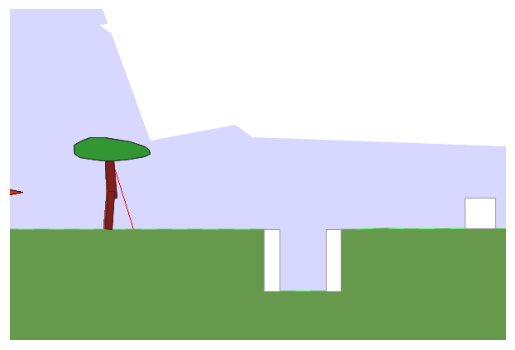

In [8]:
# env = rld.make("rldurham/Walker", render_mode="rgb_array")
env = rld.make("rldurham/Walker", render_mode="rgb_array", hardcore=True) # only attempt this when your agent has solved the non-hardcore version

# get statistics, logs, and videos
env = rld.Recorder(
    env,
    smoothing=10,                       # track rolling averages (useful for plotting)
    video=True,                         # enable recording videos
    video_folder="Hard_TQC_9/videos",              # folder for videos
    video_prefix="hqcb32-agent-video-hardcore",  # prefix for videos (replace xxxx00 with your username)
    logs=True,                          # keep logs
)

# training on CPU recommended
rld.check_device()

# environment info
rld.env_info(env, print_out=True)

# render start image (reset just to render image)
env.reset(seed=42)
rld.render(env)

**Collect episodes and train the agent**

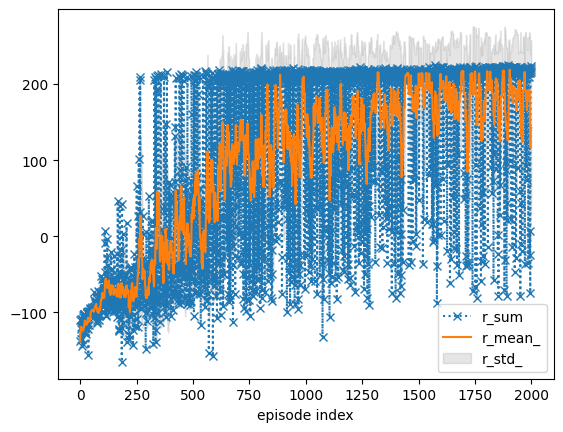

In [9]:
# in the submission please use seed_everything with seed 42 for verification
seed, observation, info = rld.seed_everything(42, env)

# initialise agent - 2000 on hard env
agent = Agent(env)
max_episodes = 2000

# track statistics for plotting
tracker = rld.InfoTracker()

# switch video recording off (only switch on every x episodes as this is slow)
env.video = False

# training procedure
for episode in range(max_episodes):
    
    # recording statistics and video can be switched on and off (video recording is slow!)
    env.info = True                 # usually tracking every episode is fine
    env.video = episode % 25 == 0  # record videos every 25 episodes (set BEFORE calling reset!)

    # reset for new episode
    observation, info = env.reset()

    # run episode
    done = False
    while not done:
        
        s = observation
        
        # select the agent action
        action = agent.sample_action(observation)

        action_np = action.detach().cpu().numpy() if isinstance(action, torch.Tensor) else action

        # take action in the environment
        observation, reward, terminated, truncated, info = env.step(action_np)
        
        # check whether done
        done = terminated or truncated

        # remember
        agent.put_data(s, action, reward, observation, terminated)

    # train the agent after each episode
    agent.train()
            
    # track and plot statistics
    tracker.track(info)
    if (episode + 1) % 10 == 0:
        tracker.plot(r_mean_=True, r_std_=True, r_sum=dict(linestyle=':', marker='x'))

# don't forget to close environment (e.g. triggers last video save)
env.close()

# write log file (for coursework)
env.write_log(folder="Hard_TQC_9/logs", file="hqcb32-agent-log-hardcore.txt")  # replace xxxx00 with your username